This notebook is used to evaluate the phenotypical relationship of the disease trajectory, both from a molecular and an epidemiological point of view

In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import pickle as pk
import ast
import seaborn as sns
import matplotlib.pyplot as plt



In [2]:
#Here, we import the harmonized gene-disease associations
with open('output/allsources_icd_gene_dict_unified.pickle', 'rb') as handle:
    allsources_icd_gene_dict_unified = pk.load(handle)

In [9]:
def enrichment_from_genelist(gene_list,libraries):   #This function returns the enrichment df for GOBP,GOCC,GOMF,KeGG  
    import gseapy as gp
    enr_df_dict={}
    for l in libraries:
        enr_df = gp.enrichr(gene_list=gene_list,
                             gene_sets=l,
                             organism='human', # don't forget to set organism to the one you desired! e.g. Yeast
                             outdir=None, # don't write to disk
                            )
        enr_df_dict[l]=enr_df

    return enr_df_dict

lib_list=['Human_Phenotype_Ontology']



In [155]:
import re

def find_enclosed(s): 
    # find all matches
    matches = re.findall(r"\((.*?)\)", s) 
    # if there are no matches return None
    if len(matches) == 0:
        return None
    # if there is only one match return it without a list
    elif len(matches) ==  1:
        return matches[0]
    else:
        right_element = []
        for el in matches:
            if el[:3]=="HP:":
                right_element.append(el)
        return right_element[0]


def terms_extraction(enriched_terms):
    id_list1=[]
    for el in enriched_terms:
        id_list1.append(find_enclosed(el))
    return id_list1



In [23]:
#Let's extract for each ICD code the HPO terms that are enriched based on the genetic overlap

ICD_HPO_Genetic_dict = {}

for ICD,geneset in allsources_icd_gene_dict_unified.items():
    genelist = [i for i in list(geneset) if str(i)!='nan']
    try:
        icd_enr_df = enrichment_from_genelist(genelist,lib_list)
        icd_enr_aggdf = pd.concat([v.res2d for v in list(icd_enr_df.values())], join="inner")
        term_list = icd_enr_aggdf[icd_enr_aggdf['Adjusted P-value']<0.05]['Term'].tolist()
        ICD_HPO_Genetic_dict[ICD] = term_list
    except:
        pass


In [25]:

with open('output/ICD_HPO_Genetic_dict.pickle', 'wb') as handle:
    pk.dump(ICD_HPO_Genetic_dict, handle, protocol=pk.HIGHEST_PROTOCOL)

In [ ]:
with open('output/ICD_HPO_Genetic_dict.pickle', 'rb') as handle:
    ICD_HPO_Genetic_dict = pk.load(handle)

In [9]:
#Now, let's extract the HPO terms that have been associated from the ICD code directly
#from https://github.com/emcarthur/phecode-HPO-map/tree/main/data

#from ICD to Phecode
icd10_phecode_df = pd.read_csv("input/ICD10.tsv", sep="\t")

#from Phecode to HPO
phecode_HPO_df_1 = pd.read_csv("input/hpo-phecode1.2_links.tsv", sep="\t")
phecode_HPO_df_2 = pd.read_csv("input/hpo-phecodeX_links.tsv", sep="\t")



In [6]:
new_icd_list = []
for icd in icd10_phecode_df['ICD10_code']:
    new_icd_list.append(icd.split(".")[0])

icd10_phecode_df['New_ICD10_code'] = new_icd_list

In [128]:

# Preprocess: Create dictionaries for quick lookup of hpo_codes by phecode
phecode1_hpo_map = phecode_HPO_df_1.groupby('phecode1.2_code')['hpo_code'].apply(list).to_dict()
phecodeX_hpo_map = phecode_HPO_df_2.groupby('phecodeX_code')['hpo_code'].apply(list).to_dict()

# Build ICD_HPO_dict
ICD_HPO_dict = {}
for icd in ICD_HPO_Genetic_dict.keys():
    hpo_list = []
    
    # Filter rows for the current ICD
    icd_rows = icd10_phecode_df[icd10_phecode_df['New_ICD10_code'] == icd]
    
    # Extract HPO codes for phecode1.2
    for row,values in icd_rows.iterrows():
        phecode12_list = values['phecode1.2_codeList']
        if str(phecode12_list)!='nan':
            for phecode in phecode12_list:
                float_phecode = float(phecode)
                hpo_list.extend(phecode1_hpo_map.get(float_phecode, []))
        
    # Extract HPO codes for phecodeX
    for row,values in icd_rows.iterrows():
        phecodeX_list = values['phecodeX_codeList']
        if str(phecodeX_list)!='nan':
            for phecode in phecodeX_list:
                hpo_list.extend(phecodeX_hpo_map.get(phecode, []))
    
    # Assign unique HPO codes to the current ICD
    ICD_HPO_dict[icd] = set(hpo_list)

In [129]:
with open('output/ICD_HPO_dict.pickle', 'wb') as handle:
    pk.dump(ICD_HPO_dict, handle, protocol=pk.HIGHEST_PROTOCOL)

In [130]:
ICD_HPO_Genetic_length = []
ICD_HPO_len = []

for icd,hpo_list in ICD_HPO_Genetic_dict.items():
    ICD_HPO_Genetic_length.append(len(hpo_list))

for icd,hpo_list in ICD_HPO_dict.items():
    ICD_HPO_len.append(len(hpo_list))

print(np.mean(ICD_HPO_Genetic_length))
print(np.mean(ICD_HPO_len))

183.9345063538612
49.26295210166178


In [176]:
shared_ICD = []

for icd,hpo_list in ICD_HPO_Genetic_dict.items():
    if len(hpo_list)>0 and len(ICD_HPO_dict[icd])>0:
        shared_ICD.append(icd)

print(len(shared_ICD))

901


In [156]:
ICD_HPO_Genetic_extracted_terms_dict = {}
for icd, termlist in ICD_HPO_Genetic_dict.items():
    ICD_HPO_Genetic_extracted_terms_dict[icd] = terms_extraction(termlist)

/var/folders/0b/z0_jtrl111x5sn006y224x0w0000gq/T/ipykernel_9049/1435685967.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bplot = plt.boxplot(comparing_group_list,


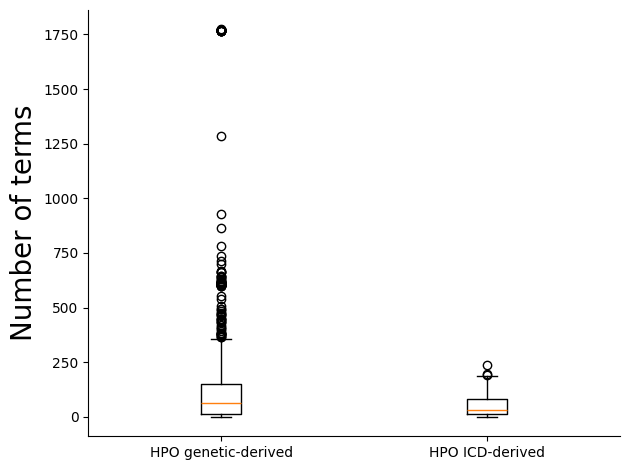

In [137]:

import matplotlib.ticker
fig1, ax1 = plt.subplots()
labels=['HPO genetic-derived','HPO ICD-derived']
plt.ylabel('Number of terms',fontsize=20)
#plt.xlabel('Jaccard index',fontsize=20)
#plt.yscale('log')
comparing_group_list=[ICD_HPO_Genetic_length,ICD_HPO_len]
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['bottom'].set_visible(True)
ax1.spines['left'].set_visible(True)
bplot = plt.boxplot(comparing_group_list,
                     notch=False,  # notch shape
                     vert=True,  # vertical box alignment  
                     labels=labels)  # will be used to label x-ticks

plt.tight_layout()
plt.savefig('Figures/HPO_boxplotcomparison.pdf',format='pdf',dpi=300, bbox_inches = "tight")

plt.show()

In [138]:
from scipy import stats
import numpy as np


t_value,p_value=stats.ttest_ind(ICD_HPO_Genetic_length,ICD_HPO_len)
p_value

4.0602269555278375e-30

In [169]:
tot_HPO_terms = []

for icd,termlist in ICD_HPO_Genetic_extracted_terms_dict.items():
    tot_HPO_terms.extend(termlist)

ICD_HPO_up_dict = {}

for icd,termlist in ICD_HPO_dict.items():
    n_termlist = [i.replace("_",":") for i in termlist]
    ICD_HPO_up_dict[icd] = n_termlist
    tot_HPO_terms.extend(n_termlist)

HPO_background = len(set(tot_HPO_terms))


In [170]:

def overlap_lists(lstA, lstB, background):
    import scipy.stats as stats
    """
    Accepts to lists
    M is the population size (previously N)
    n is the number of successes in the population
    N is the sample size (previously n)
    x is still the number of drawn “successes”
    """
    setA= set(lstA)
    setB= set(lstB)
    M= background #total number of elements
    n= len(setA)
    N= len(setB)
    x= len(setA.intersection(setB))


    return str(stats.hypergeom.sf(x-1, M, n, N))



#Here we define the adjustment
from statsmodels.sandbox.stats.multicomp import multipletests
def fdr_adjustment(list_of_pvals,alpha):    
    return multipletests(list_of_pvals,alpha=alpha,method='fdr_bh')[1] #the benjamin hochberg method is used

In [173]:
ICD_HPO_Genetic_match_pval_dict = {}
ICD_HPO_Genetic_match_fdr_dict = {}
ICD_HPO_Genetic_match_sigfdr_dict = {}

for icd,hpo_set in ICD_HPO_Genetic_extracted_terms_dict.items():
    p_value = float(overlap_lists(hpo_set,ICD_HPO_up_dict[icd],HPO_background))
    ICD_HPO_Genetic_match_pval_dict[icd] = p_value

adj_pval=fdr_adjustment(list(ICD_HPO_Genetic_match_pval_dict.values()),0.05)
pair_list=list(ICD_HPO_Genetic_match_pval_dict.keys())
for i in range(len(adj_pval)):
    ICD_HPO_Genetic_match_fdr_dict[pair_list[i]]=adj_pval[i]
        
for dispair,fdr in ICD_HPO_Genetic_match_fdr_dict.items():
    if fdr<0.05:
        ICD_HPO_Genetic_match_sigfdr_dict[dispair]=fdr
    
print(len(ICD_HPO_Genetic_match_sigfdr_dict))

216


In [174]:
len(ICD_HPO_Genetic_extracted_terms_dict)

1023

In [179]:
for icd,hpo_list in ICD_HPO_up_dict.items():
    if len(hpo_list)<5 and len(ICD_HPO_Genetic_extracted_terms_dict[icd])>50:
        print(icd)

N80
E14
E12
I64
O00
O15
E32
D55-D59
E08-E13
C97
U04
B21
T30
M09
G20+
M68
F62
I98
H45
E90
M73
K93
H06
H48
F83
H62
H58
H03
K36


In [180]:
ICD_HPO_Genetic_dict['I64']

['Autosomal dominant inheritance (HP:0000006)',
 'Epistaxis (HP:0000421)',
 'Menorrhagia (HP:0000132)',
 'Deep venous thrombosis (HP:0002625)',
 'Splenomegaly (HP:0001744)',
 'Gingival bleeding (HP:0000225)',
 'Prolonged bleeding time (HP:0003010)',
 'Bruising susceptibility (HP:0000978)',
 'Hepatomegaly (HP:0002240)',
 'Joint swelling (HP:0001386)',
 'Autosomal recessive inheritance (HP:0000007)',
 'Opacification of the corneal stroma (HP:0007759)',
 'Skin rash (HP:0000988)',
 'Prolonged partial thromboplastin time (HP:0003645)',
 'Amyloidosis (HP:0011034)',
 'Joint hemorrhage (HP:0005261)',
 'Pseudobulbar signs (HP:0002200)',
 'Dysphonia (HP:0001618)',
 'Abnormal platelet function (HP:0011869)',
 'Abnormality of the common coagulation pathway (HP:0010990)',
 'Impaired platelet aggregation (HP:0003540)',
 'Stroke (HP:0001297)',
 'Aplasia/Hypoplasia of the lens (HP:0008063)',
 'Thrombophlebitis (HP:0004418)',
 'Corneal dystrophy (HP:0001131)',
 'Hematuria (HP:0000790)',
 'Nephropathy (

In [181]:
ICD_HPO_up_dict['I64']

[]

In [ ]:
#Let's import the latest obo file from HPO 
import obonet
graph = obonet.read_obo("input/hp_2023.obo")
#Let's reverse the ontology
graph_up = nx.DiGraph.reverse(graph)
#This function is the first step for the resnik score calculation
import pandas as pd
import pickle as pk
import matplotlib.pyplot as plt
import itertools as it
import networkx as nx
from collections import (defaultdict,Counter)
import random as rd
import numpy as np
def precalc_lower_bounds(G):
    """Pre-calculate the number of lower bounds of the graph nodes
    """
    G.lower_bounds = Counter()
    for n in G:
        G.lower_bounds[n] += 1
        for ans in nx.ancestors(G, n):
            G.lower_bounds[ans] += 1
   # G.descriptors.add("Pre-calculated lower bounds")
#This function is the second step for the resnik score calculation
def information_content(G, term):
    """Information content
    Args:
        G(Ontology Graph): Ontology graph object
        term(str): ontolgy term
    Returns:
        str - Information content
    Raises:
        PGSSLookupError: The term was not found in Ontology Graph
        PGSSInvalidOperation: see `pygosemsim.similarity.precalc_lower_bounds`
    """
    if term not in G.lower_bounds:
        raise exception.PGSSLookupError(f"Missing term: {term}")
    freq = G.lower_bounds[term] / len(G)
    return round(-1 * math.log2(freq), 3)

#This function is the third step for the resnik score calculation
def lowest_common_ancestor(G, term1, term2):
    """Naive implementation of lowest common ancestor (LCA)
    Args:
        G(GoGraph): Graph object
        term1(str): Ontology term 1
        term2(str): Ontology term 2
    Returns:
        str - Lowest common ancestor term
        or None if the terms have no common ancestors
    Raises:
        PGSSLookupError: The term was not found in Ontology Graph
        PGSSInvalidOperation: see `pygosemsim.similarity.precalc_lower_bounds`
    """
    if term1 not in G:
        raise exception.PGSSLookupError(f"Missing term: {term1}")
    if term2 not in G:
        raise exception.PGSSLookupError(f"Missing term: {term2}")
    lb1 = nx.ancestors(G, term1) | {term1}
    lb2 = nx.ancestors(G, term2) | {term2}
    common_ans = lb1 & lb2
    if not common_ans:
        return
    return min(common_ans, key=lambda x: G.lower_bounds[x])
import math
#This function would return the resnik score between two terms
def resnik(G, term1, term2):
    """Semantic similarity based on Resnik method
    Args:
        G(GoGraph): Ontology graph object
        term1(str): term 1
        term2(str): term 2
    Returns:
        float - Resnik similarity value (Information content of LCA)
        or None if the terms have no common ancestors
    Raises:
        PGSSLookupError: The term was not found in GoGraph
        PGSSInvalidOperation: see `pygosemsim.similarity.precalc_lower_bounds`
    """
    mica = lowest_common_ancestor(G, term1, term2)
    if mica is not None:
        return information_content(G, mica)

precalc_lower_bounds(graph_up)


def resnik_terms_calculation(terms,ontology_tree):
    resnik_id_list1=[]
    pairwise_list = list(it.combinations(terms, 2))
    for i,j in pairwise_list:
        try:
            resnik_id_list1.append(round(resnik(ontology_tree, i, j),3))
        except:
            try:
                resnik_id_list1.append(round(resnik(ontology_tree, j, i),3))
            except:
                pass 
    return resnik_id_list1



In [ ]:

hpo_pairwise_list = list(it.combinations(graph_up.nodes(), 2))
graph_up_resnik={}
for hpo_term_pair in hpo_pairwise_list:
        try:
            try:
                graph_up_resnik[hpo_term_pair[0],hpo_term_pair[1]]=(round(resnik(graph_up, hpo_term_pair[0],hpo_term_pair[1]),3))
            except:
                graph_up_resnik[hpo_term_pair[0],hpo_term_pair[1]]=(round(resnik(graph_up, hpo_term_pair[1],hpo_term_pair[0]),3))
        except:
            pass

with open('output/hpo_graph_up_resnik.pickle', 'wb') as handle:
    pk.dump(graph_up_resnik, handle, protocol=pk.HIGHEST_PROTOCOL)

In [ ]:
with open('output/hpo_graph_up_resnik.pickle', 'rb') as handle:
    hpo_graph_up_resnik = pk.load(handle)

In [ ]:

def resnik_calculation_simplified(terms, stored_resnik, ontology_tree):
    resnik_id_list1=[]
    pairwise_list = list(it.combinations(terms, 2))
    for i,j in pairwise_list:
        try:
            try:
                try:
                    resnik_id_list1.append(stored_resnik[i,j])
                except:
                    resnik_id_list1.append(stored_resnik[j,i])
            except:
                resnik_id_list1.append(round(resnik(graph_up, i,j),3))
        except:
             pass 
    return resnik_id_list1

def random_resnik_expectation(terms, resnik_id_list1,stored_resnik, ontology_tree):
    term_sample_size = len(set(terms))
    avg_random_resnik_list = []
    if term_sample_size>2:
        while len(avg_random_resnik_list) < 1000:
            term_sample = rd.sample(ontology_tree.nodes(), term_sample_size)
            resnik_randomid_list1 = []
            pairwise_list = list(it.combinations(term_sample, 2))
            for i, j in pairwise_list:
                try:
                    try:
                        resnik_randomid_list1.append(stored_resnik[i,j])
                    except:
                        resnik_randomid_list1.append(stored_resnik[j,i])
                except:
                    resnik_randomid_list1.append(round(resnik(graph_up, i,j),3))
            resnik_randomid_list1_cleaned = [x for x in resnik_randomid_list1 if str(x) != 'nan']
            if str(np.mean(resnik_randomid_list1_cleaned)) != 'nan':
                avg_random_resnik_list.append(np.mean(resnik_randomid_list1_cleaned))
            else:
                pass
        mu = np.mean(avg_random_resnik_list)
        std = np.std(avg_random_resnik_list)
        z = (np.mean(resnik_id_list1) - mu) / std
    else:
        z = 'nan'
    return z

In [ ]:
#This makes a within comparison
ICD_HPO_Genetic_extracted_terms_resnik_dict={}

for icd,hpo_symbol_list in ICD_HPO_Genetic_extracted_terms_dict.items():
    ICD_HPO_Genetic_extracted_terms_resnik_dict[icd]=resnik_calculation_simplified(hpo_symbol_list,hpo_graph_up_resnik,graph_up)

ICD_HPO_Genetic_extracted_terms_resnik_zscore_dict={}

for dis,hpo_list in ICD_HPO_Genetic_extracted_terms_resnik_dict.items():
    ICD_HPO_Genetic_extracted_terms_resnik_zscore_dict[dis]=random_resnik_expectation(hpo_list,ICD_HPO_Genetic_extracted_terms_resnik_dict[dis],hpo_graph_up_resnik,graph_up)


    

In [ ]:
with open('output/ICD_HPO_Genetic_extracted_terms_resnik_dict.pickle', 'wb') as handle:
    pk.dump(ICD_HPO_Genetic_extracted_terms_resnik_dict, handle, protocol=pk.HIGHEST_PROTOCOL)

with open('output/ICD_HPO_Genetic_extracted_terms_resnik_zscore_dict.pickle', 'wb') as handle:
    pk.dump(ICD_HPO_Genetic_extracted_terms_resnik_zscore_dict, handle, protocol=pk.HIGHEST_PROTOCOL)

In [2]:
#Let's import the results
with open('output/ICD_HPO_Genetic_extracted_terms_resnik_dict.pickle', 'rb') as handle:
    ICD_HPO_Genetic_extracted_terms_resnik_dict = pk.load(handle)

with open('output/ICD_HPO_Genetic_extracted_terms_resnik_zscore_dict.pickle', 'rb') as handle:
    ICD_HPO_Genetic_extracted_terms_resnik_zscore_dict = pk.load(handle)

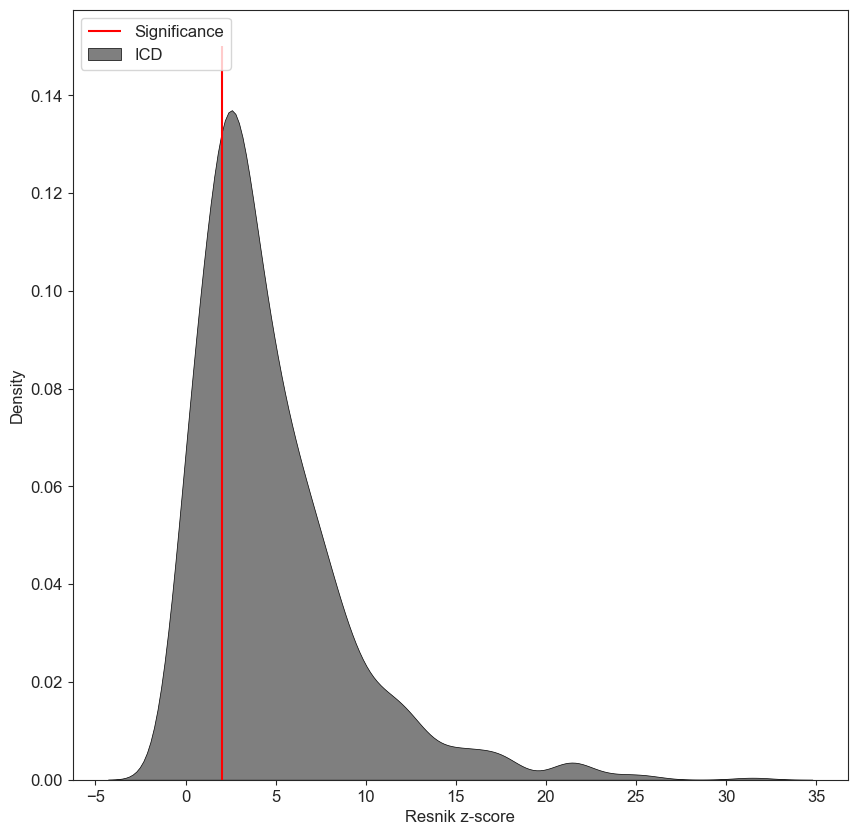

In [8]:
#Let's plot the distribution of all lcc z-scores
ICD_HPO_Genetic_extracted_terms_resnik_zscore_list = [i for i in ICD_HPO_Genetic_extracted_terms_resnik_zscore_dict.values() if str(i)!='nan']
# plot distributions for non-sampled case
sns.set_style('white')
sns.set_style("ticks", {"xtick.major.size": 15, "ytick.major.size": 15})
plt.figure(figsize=(10,10))
plt.vlines(2,ymin=0,ymax=0.15,color='r',label='Significance')
sns.kdeplot(ICD_HPO_Genetic_extracted_terms_resnik_zscore_list,color='k',lw=.5,alpha=.5,fill=True,label='ICD')

plt.legend(loc='upper left',fontsize=12)
plt.ylabel('Density',fontsize=12)
plt.xlabel('Resnik z-score',fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.savefig('Figures/ICD_HPO_Resnik_Distribution.pdf',format='pdf',dpi=300, bbox_inches = "tight")

In [10]:
len([i for i in ICD_HPO_Genetic_extracted_terms_resnik_zscore_list if i>2])

656

In [11]:
len(ICD_HPO_Genetic_extracted_terms_resnik_zscore_list)

869